# Process the AGAP airborne gravity data

We try to recreate the BAS processing steps, as outlined here: https://data.bas.ac.uk/full-record.php?id=GB/NERC/BAS/PDC/01310

In [1]:
%load_ext autoreload
%autoreload 2

import boule as bl
import cmocean
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import verde as vd

import airbornegeo

/home/sungw937/airbornegeo/.pixi/envs/default/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load data

This is a subset of the BAS AGAP survey over Antarctica's Gamburtsev Subglacial Mountains. The file is download and subset in the notebook `AGAP_survey`.

In [2]:
data_df = pd.read_csv("data/AGAP_gravity_survey.csv")

print(data_df.columns)
data_df.head()

Index(['Lon', 'Lat', 'Height_WGS1984', 'Date', 'Time', 'ST', 'CC', 'RB',
       'XACC', 'LACC', 'Still', 'Base', 'ST_real', 'Beam_vel', 'rec_grav',
       'Abs_grav', 'VaccCor', 'EotvosCor', 'LatCor', 'FaCor', 'HaccCor',
       'Free_air', 'FAA_filt', 'FAA_clip', 'Level_cor', 'FAA_level',
       'Fa_4600m', 'easting', 'northing', 'line_name', 'line', 'unixtime'],
      dtype='str')


,Lon,Lat,Height_WGS1984,Date,Time,ST,CC,RB,XACC,LACC,...,FAA_filt,FAA_clip,Level_cor,FAA_level,Fa_4600m,easting,northing,line_name,line,unixtime
0,77.252450,-80.583923,4156.1,2008-12-17,0 days 09:42:48,11934.47,2.61,-659.0,-49.0,273.0,...,49.38,49.38,7.03,42.4,40.8,1.000024e+06,226237.330771,11_DA500,1,1.229507e+09
1,77.252672,-80.583377,4156.0,2008-12-17,0 days 09:42:49,11934.47,2.72,-368.6,-321.0,230.0,...,49.45,49.45,7.04,42.4,40.8,1.000083e+06,226246.631269,11_DA500,1,1.229507e+09
2,77.252901,-80.582831,4156.1,2008-12-17,0 days 09:42:50,11888.95,-2.08,703.1,433.0,146.0,...,49.52,49.52,7.04,42.5,40.9,1.000142e+06,226255.809132,11_DA500,1,1.229507e+09
3,77.253131,-80.582285,4156.4,2008-12-17,0 days 09:42:51,11888.95,0.50,625.1,566.0,223.0,...,49.58,49.58,7.03,42.5,40.9,1.000201e+06,226264.969079,11_DA500,1,1.229507e+09
4,77.253358,-80.581740,4156.6,2008-12-17,0 days 09:42:52,11888.95,-1.73,575.1,108.0,205.0,...,49.65,49.65,7.04,42.6,41.0,1.000260e+06,226274.156809,11_DA500,1,1.229507e+09


In [3]:
# turn to geopandas geodataframe
data_df = gpd.GeoDataFrame(
    data_df,
    geometry=gpd.points_from_xy(x=data_df.easting, y=data_df.northing),
    crs="EPSG:3031",
)

## Distance along line

In [4]:
data_df["distance_along_line"] = airbornegeo.along_track_distance(
    data_df,
    groupby_column="line",
)
data_df.head()

,Lon,Lat,Height_WGS1984,Date,Time,ST,CC,RB,XACC,LACC,...,Level_cor,FAA_level,Fa_4600m,easting,northing,line_name,line,unixtime,geometry,distance_along_line
0,77.252450,-80.583923,4156.1,2008-12-17,0 days 09:42:48,11934.47,2.61,-659.0,-49.0,273.0,...,7.03,42.4,40.8,1.000024e+06,226237.330771,11_DA500,1,1.229507e+09,POINT (1000023.79 226237.331),0.000000
1,77.252672,-80.583377,4156.0,2008-12-17,0 days 09:42:49,11934.47,2.72,-368.6,-321.0,230.0,...,7.04,42.4,40.8,1.000083e+06,226246.631269,11_DA500,1,1.229507e+09,POINT (1000082.905 226246.631),59.842447
2,77.252901,-80.582831,4156.1,2008-12-17,0 days 09:42:50,11888.95,-2.08,703.1,433.0,146.0,...,7.04,42.5,40.9,1.000142e+06,226255.809132,11_DA500,1,1.229507e+09,POINT (1000142.048 226255.809),119.693401
3,77.253131,-80.582285,4156.4,2008-12-17,0 days 09:42:51,11888.95,0.50,625.1,566.0,223.0,...,7.03,42.5,40.9,1.000201e+06,226264.969079,11_DA500,1,1.229507e+09,POINT (1000201.195 226264.969),179.545645
4,77.253358,-80.581740,4156.6,2008-12-17,0 days 09:42:52,11888.95,-1.73,575.1,108.0,205.0,...,7.04,42.6,41.0,1.000260e+06,226274.156809,11_DA500,1,1.229507e+09,POINT (1000260.224 226274.157),239.285174


## Relative gravity
$$
g_{rel} = s (t +(b k)+c)
$$

where $g_{rel}$ is the relative gravity, $t$ is the true spring tension, $b$ is the beam velocity, $k$ is 30, $c$ is the cross-coupling, and $s$ is the meter scale value, which is 0.9966.

In [5]:
data_df["grav_relative"] = 0.9966 * (
    data_df["ST_real"] + (data_df["Beam_vel"] * 30) + data_df["CC"]
)
data_df.head()

,Lon,Lat,Height_WGS1984,Date,Time,ST,CC,RB,XACC,LACC,...,FAA_level,Fa_4600m,easting,northing,line_name,line,unixtime,geometry,distance_along_line,grav_relative
0,77.252450,-80.583923,4156.1,2008-12-17,0 days 09:42:48,11934.47,2.61,-659.0,-49.0,273.0,...,42.4,40.8,1.000024e+06,226237.330771,11_DA500,1,1.229507e+09,POINT (1000023.79 226237.331),0.000000,18941.957628
1,77.252672,-80.583377,4156.0,2008-12-17,0 days 09:42:49,11934.47,2.72,-368.6,-321.0,230.0,...,42.4,40.8,1.000083e+06,226246.631269,11_DA500,1,1.229507e+09,POINT (1000082.905 226246.631),59.842447,32258.636454
2,77.252901,-80.582831,4156.1,2008-12-17,0 days 09:42:50,11888.95,-2.08,703.1,433.0,146.0,...,42.5,40.9,1.000142e+06,226255.809132,11_DA500,1,1.229507e+09,POINT (1000142.048 226255.809),119.693401,26746.641174
3,77.253131,-80.582285,4156.4,2008-12-17,0 days 09:42:51,11888.95,0.50,625.1,566.0,223.0,...,42.5,40.9,1.000201e+06,226264.969079,11_DA500,1,1.229507e+09,POINT (1000201.195 226264.969),179.545645,9943.048302
4,77.253358,-80.581740,4156.6,2008-12-17,0 days 09:42:52,11888.95,-1.73,575.1,108.0,205.0,...,42.6,41.0,1.000260e+06,226274.156809,11_DA500,1,1.229507e+09,POINT (1000260.224 226274.157),239.285174,19539.558852


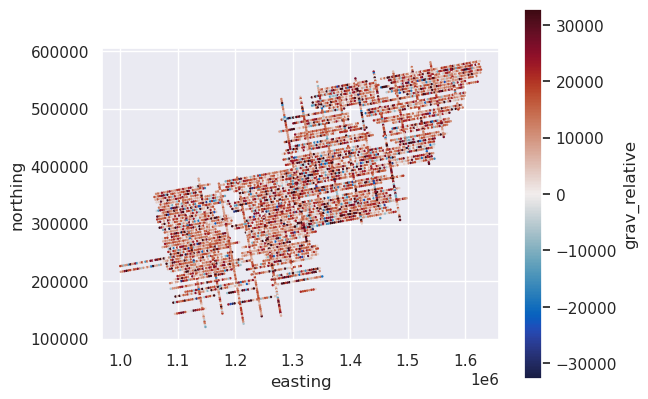

In [6]:
max_abs = vd.maxabs(data_df.grav_relative, percentile=95)

data_df[::50].plot.scatter(
    "easting",
    "northing",
    c="grav_relative",
    s=0.6,
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
).set_aspect("equal")

In [7]:
# for now just use there values
data_df = data_df.drop(columns=["grav_relative"], errors="ignore")
data_df["grav_relative"] = data_df.rec_grav

## Absolute gravity

Still readings are in mGal and were calculating assuming a 2nd order best fit to the approximately linear drift of the meter observed at the tie down points. For each line, there are 2-5 unique still values. For the whole survey, the base station readings are all equal to 981970.73 mGal.

Absolute gravity is then calculated as:
$$
g_{abs} = g_{rel} - g_{still} + g_{base}
$$

In [8]:
data_df["grav_absolute"] = data_df["grav_relative"] - data_df["Still"] + data_df["Base"]
data_df.head()

,Lon,Lat,Height_WGS1984,Date,Time,ST,CC,RB,XACC,LACC,...,Fa_4600m,easting,northing,line_name,line,unixtime,geometry,distance_along_line,grav_relative,grav_absolute
0,77.252450,-80.583923,4156.1,2008-12-17,0 days 09:42:48,11934.47,2.61,-659.0,-49.0,273.0,...,40.8,1.000024e+06,226237.330771,11_DA500,1,1.229507e+09,POINT (1000023.79 226237.331),0.000000,18941.96,988774.73
1,77.252672,-80.583377,4156.0,2008-12-17,0 days 09:42:49,11934.47,2.72,-368.6,-321.0,230.0,...,40.8,1.000083e+06,226246.631269,11_DA500,1,1.229507e+09,POINT (1000082.905 226246.631),59.842447,32258.64,1002091.41
2,77.252901,-80.582831,4156.1,2008-12-17,0 days 09:42:50,11888.95,-2.08,703.1,433.0,146.0,...,40.9,1.000142e+06,226255.809132,11_DA500,1,1.229507e+09,POINT (1000142.048 226255.809),119.693401,26746.64,996579.41
3,77.253131,-80.582285,4156.4,2008-12-17,0 days 09:42:51,11888.95,0.50,625.1,566.0,223.0,...,40.9,1.000201e+06,226264.969079,11_DA500,1,1.229507e+09,POINT (1000201.195 226264.969),179.545645,9943.05,979775.82
4,77.253358,-80.581740,4156.6,2008-12-17,0 days 09:42:52,11888.95,-1.73,575.1,108.0,205.0,...,41.0,1.000260e+06,226274.156809,11_DA500,1,1.229507e+09,POINT (1000260.224 226274.157),239.285174,19539.56,989372.33


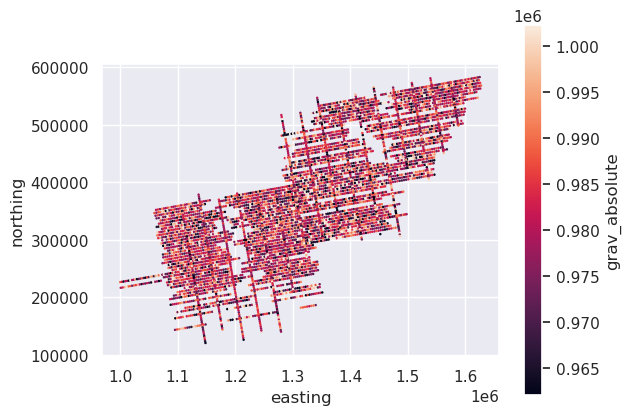

In [9]:
cpt_lims = vd.minmax(data_df.grav_absolute, min_percentile=5, max_percentile=95)

data_df[::50].plot.scatter(
    "easting",
    "northing",
    c="grav_absolute",
    s=0.6,
    vmin=cpt_lims[0],
    vmax=cpt_lims[1],
).set_aspect("equal")

In [10]:
# for now just use their values
data_df = data_df.drop(columns=["grav_absolute"], errors="ignore")
data_df["grav_absolute"] = data_df.Abs_grav

## Vertical acceleration corrections

The vertical acceleration is calculated as the 2nd derivative of flight altitude w.r.t. time with a 3 point mean filter applied after differencing to reduce short wavelength noise.

In [11]:
data_df["vertical_acceleration"] = (
    airbornegeo.nav.vertical_acceleration(
        data_df,
        groupby_column="line",
        smoothing_window=3,
        time_column="unixtime",
        height_column="Height_WGS1984",
        # time_threshold=30,
    )
    * 10**5  # convert from m/s2 to mGal
)
data_df.describe()

Segments: 100%|██████████| 100/100 [00:00<00:00, 434.87it/s]


,Lon,Lat,Height_WGS1984,ST,CC,RB,XACC,LACC,Still,Base,...,FAA_level,Fa_4600m,easting,northing,line,unixtime,distance_along_line,grav_relative,grav_absolute,vertical_acceleration
count,333993.000000,333993.000000,333993.00000,333993.000000,333993.000000,333993.000000,333993.000000,333993.000000,333993.000000,3.339930e+05,...,332881.000000,332881.000000,3.339930e+05,333993.000000,333993.000000,3.339930e+05,333993.000000,333993.000000,3.339930e+05,333993.000000
mean,74.694473,-77.357032,3274.09101,12145.789257,-4.727337,938.287885,0.079316,0.346974,12131.377650,9.819707e+05,...,5.764404,5.859209,1.326747e+06,368789.239170,50.428997,1.230609e+09,123284.855413,12062.834493,9.819022e+05,-0.521084
std,3.275538,1.439273,565.19148,229.441953,12.113072,2732.654287,831.593182,274.793794,3.422415,2.328310e-10,...,50.622019,50.016690,1.404868e+05,107003.390813,28.487341,6.317479e+05,78751.689748,12433.554222,1.243355e+04,10712.382232
min,67.782184,-80.604028,2033.90000,10888.850000,-289.120000,-12978.900000,-5683.000000,-2228.000000,12126.400000,9.819707e+05,...,-109.400000,-105.800000,1.000003e+06,119373.091133,1.000000,1.229507e+09,0.000000,-94445.680000,8.753871e+05,-83333.333333
25%,72.195832,-78.501965,3037.50000,12004.990000,-6.750000,-766.800000,-467.000000,-165.000000,12128.250000,9.819707e+05,...,-35.200000,-34.700000,1.219817e+06,290392.882616,25.000000,1.230029e+09,54950.880823,5116.520000,9.749556e+05,-5833.333333
50%,74.473328,-77.384779,3070.50000,12139.990000,-1.620000,701.400000,4.000000,-1.000000,12130.840000,9.819707e+05,...,-0.600000,-1.100000,1.325474e+06,355909.652731,50.000000,1.230651e+09,113131.098784,11949.060000,9.817891e+05,0.000000
75%,77.048547,-76.286009,3571.90000,12282.600000,0.490000,2414.000000,473.000000,164.000000,12134.450000,9.819707e+05,...,50.100000,49.200000,1.433744e+06,456787.016666,75.000000,1.231180e+09,190246.305756,18851.620000,9.886907e+05,5833.333333
max,84.220944,-74.190778,4186.20000,14371.450000,103.250000,14462.700000,5952.000000,1898.000000,12137.960000,9.819707e+05,...,121.700000,122.400000,1.627559e+06,583513.918167,100.000000,1.231625e+09,328564.082944,131758.060000,1.101600e+06,83333.333333


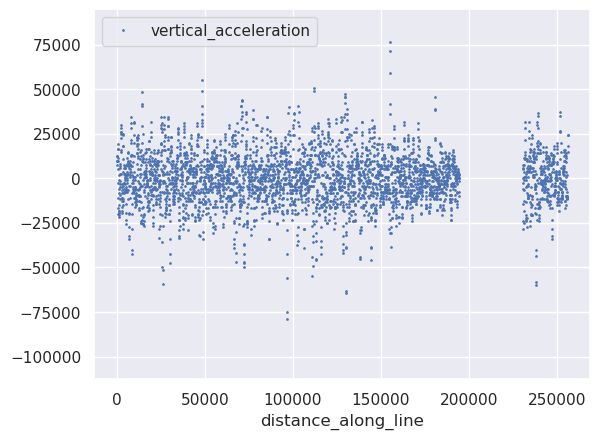

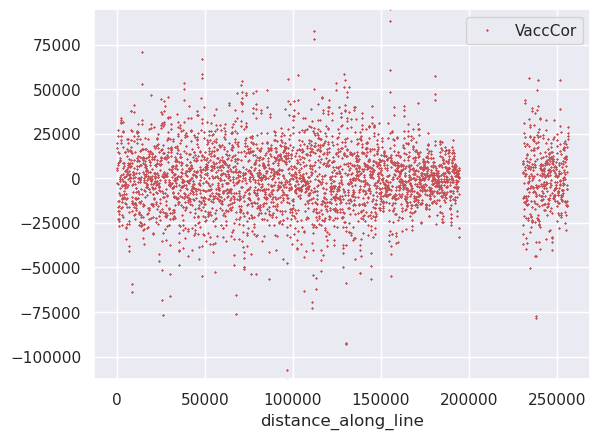

In [12]:
df = data_df[data_df.line == 1]

ylim = vd.minmax(df.VaccCor)  # , min_percentile=5, max_percentile=95)

ax = df.plot.line(
    "distance_along_line",
    "vertical_acceleration",
    style="bp",
    ms=1,
    ylim=ylim,
)

ax = df.plot.line(
    "distance_along_line",
    "VaccCor",
    style="rx",
    ms=1,
    # ax=ax,
    ylim=ylim,
)

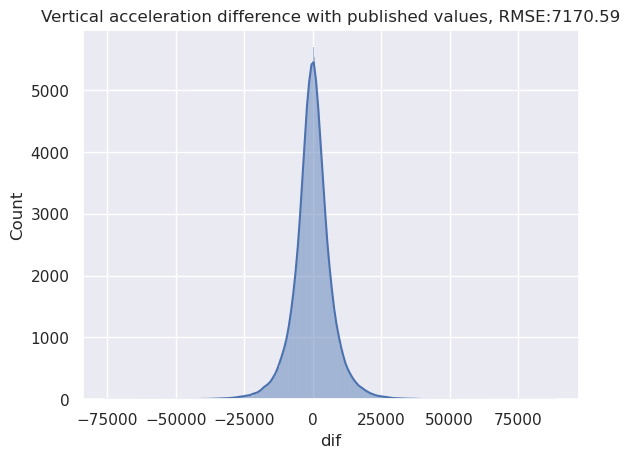

In [13]:
data_df["dif"] = data_df.VaccCor - data_df.vertical_acceleration
sns.histplot(data_df.dif, kde=True)
plt.title(
    f"Vertical acceleration difference with published values, RMSE:{round(airbornegeo.rmse(data_df.dif), 2)}"
)
plt.show()

In [14]:
# for now just use the BAS values
data_df = data_df.drop(columns=["vertical_acceleration"], errors="ignore")
data_df["vertical_acceleration"] = data_df.VaccCor

## Horizontal acceleration corrections

For this survey the approximation of Swain 1996 was used, assuming a damping of 0.707 and a platform period of 4 minutes.

In [16]:
# data_df['horizontal_acceleration'] = (
#     data_df.XACC**2 +
#     data_df.LACC**2 -
#     (np.diff(airbornegeo.eastward_velocity(
#         data_df.Lat.values, data_df.Lon.values, data_df.unixtime.values
#     ), prepend=np.nan) / data_df.unixtime.diff() )**2 -
#     (np.diff(airbornegeo.northward_velocity(
#         data_df.Lat.values, data_df.Lon.values, data_df.unixtime.values
#     ), prepend=np.nan) / data_df.unixtime.diff() )**2
# ) / 2*data_df.grav_relative

In [17]:
# for now just use the BAS values
data_df = data_df.drop(columns=["horizontal_acceleration"], errors="ignore")
data_df["horizontal_acceleration"] = data_df.HaccCor

## Eotvos correction


Segments: 100%|██████████| 100/100 [00:00<00:00, 1565.70it/s]


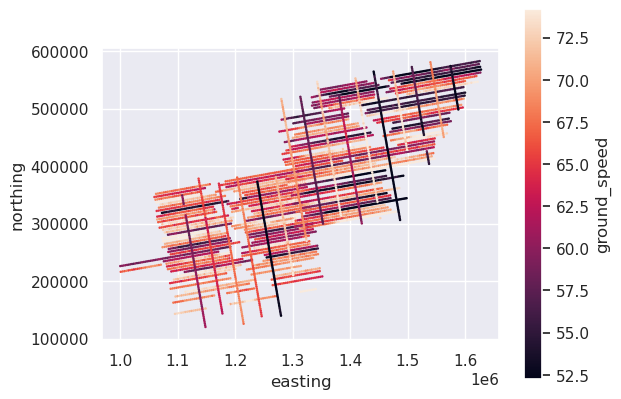

In [18]:
data_df["ground_speed"] = airbornegeo.ground_speed(
    data_df,
    easting_column="easting",
    northing_column="northing",
    time_column="unixtime",
    groupby_column="line",
)

cpt_lims = vd.minmax(data_df.ground_speed, min_percentile=5, max_percentile=95)
data_df[::50].plot.scatter(
    "easting",
    "northing",
    c="ground_speed",
    s=0.6,
    vmin=cpt_lims[0],
    vmax=cpt_lims[1],
).set_aspect("equal")

Segments: 100%|██████████| 100/100 [00:00<00:00, 903.58it/s]


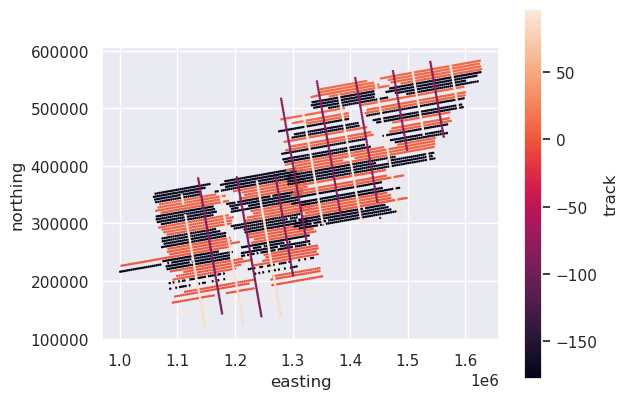

In [19]:
data_df["track"] = airbornegeo.track(
    data_df,
    latitude_column="Lat",
    longitude_column="Lon",
    groupby_column="line",
    ellipsoid=False,  # this is faster
)
cpt_lims = vd.minmax(data_df.track, min_percentile=5, max_percentile=95)
data_df[::50].plot.scatter(
    "easting",
    "northing",
    c="track",
    s=0.6,
    vmin=cpt_lims[0],
    vmax=cpt_lims[1],
).set_aspect("equal")

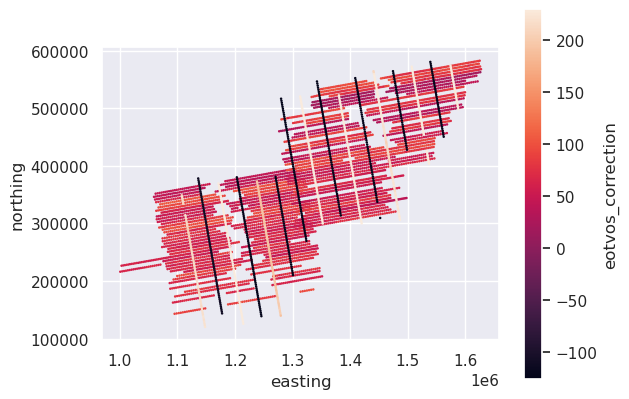

In [20]:
data_df["eotvos_correction"] = airbornegeo.eotvos_correction_glicken(
    data_df.Lat.values,
    data_df.track.values,
    data_df.ground_speed.values,
)
cpt_lims = vd.minmax(data_df.eotvos_correction, min_percentile=5, max_percentile=95)
data_df[::50].plot.scatter(
    "easting",
    "northing",
    c="eotvos_correction",
    s=0.6,
    vmin=cpt_lims[0],
    vmax=cpt_lims[1],
).set_aspect("equal")

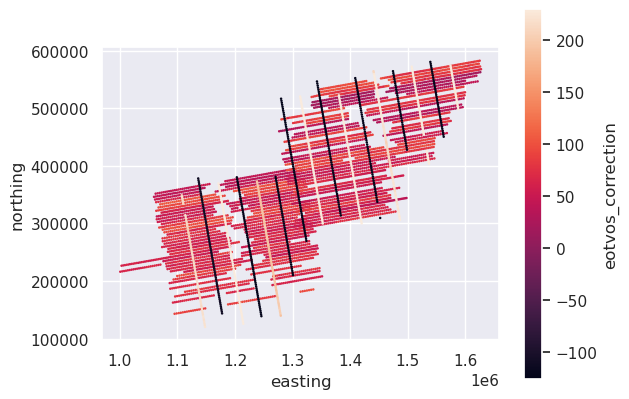

In [21]:
data_df["eotvos_correction"] = airbornegeo.eotvos_correction_glicken(
    data_df.Lat.values,
    data_df.track.values,
    data_df.ground_speed.values,
)
cpt_lims = vd.minmax(data_df.eotvos_correction, min_percentile=5, max_percentile=95)
data_df[::50].plot.scatter(
    "easting",
    "northing",
    c="eotvos_correction",
    s=0.6,
    vmin=cpt_lims[0],
    vmax=cpt_lims[1],
).set_aspect("equal")

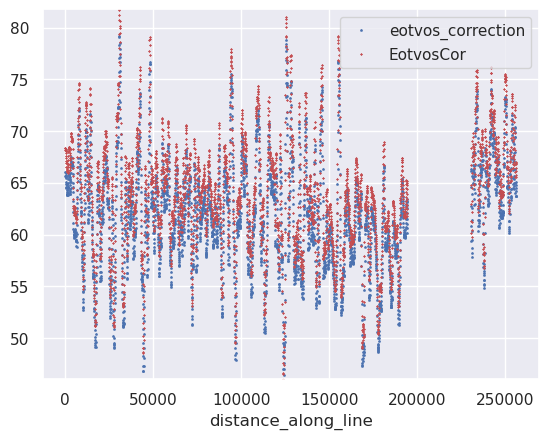

In [22]:
df = data_df[data_df.line == 1]

ylim = vd.minmax(df.EotvosCor)  # , min_percentile=5, max_percentile=95)

ax = df.plot.line(
    "distance_along_line",
    "eotvos_correction",
    style="bp",
    ms=1,
    ylim=ylim,
)

ax = df.plot.line(
    "distance_along_line",
    "EotvosCor",
    style="rx",
    ms=1,
    ax=ax,
    ylim=ylim,
)

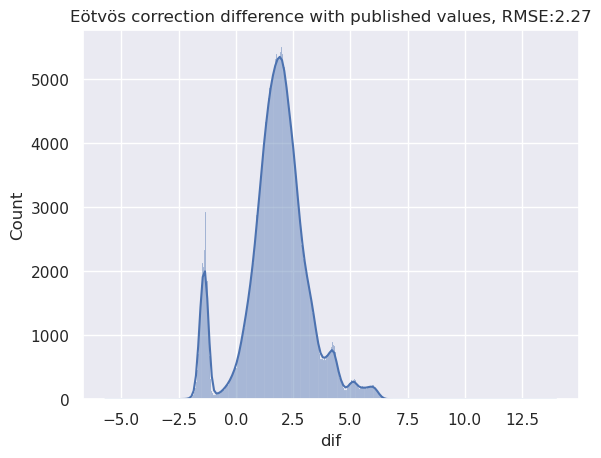

In [23]:
data_df["dif"] = data_df.EotvosCor - data_df.eotvos_correction
sns.histplot(data_df.dif, kde=True)
plt.title(
    f"Eötvös correction difference with published values, RMSE:{round(airbornegeo.rmse(data_df.dif), 2)}"
)
plt.show()

In [25]:
# for now just use the BAS values
data_df = data_df.drop(columns=["eotvos_correction"], errors="ignore")
data_df["eotvos_correction"] = data_df.EotvosCor

## Observed gravity

In [26]:
data_df["grav_observed"] = (
    data_df["grav_absolute"]
    - data_df["vertical_acceleration"]
    + data_df["eotvos_correction"]
    - (0.5 * data_df["horizontal_acceleration"])
)

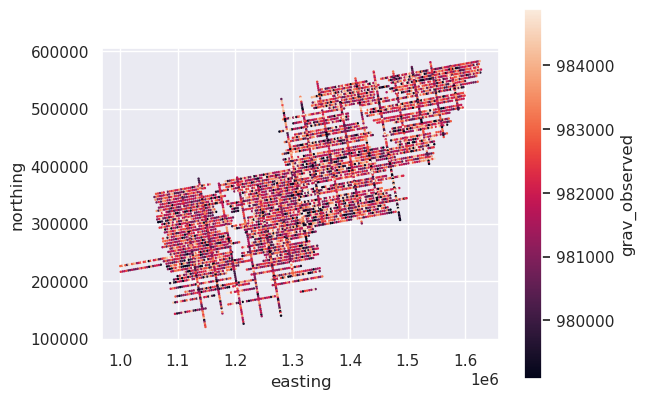

In [27]:
cpt_lims = vd.minmax(data_df.grav_observed, min_percentile=5, max_percentile=95)
data_df[::50].plot.scatter(
    "easting",
    "northing",
    c="grav_observed",
    s=0.6,
    vmin=cpt_lims[0],
    vmax=cpt_lims[1],
).set_aspect("equal")

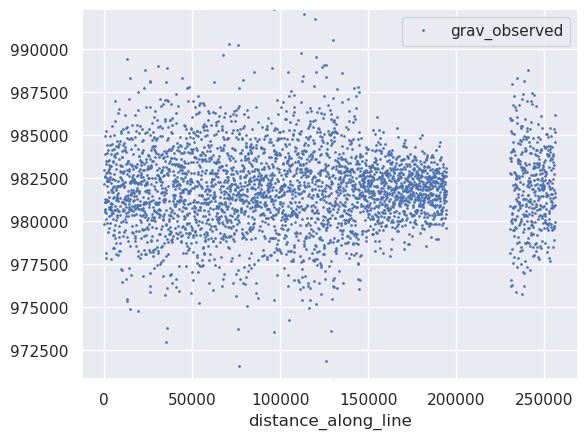

In [28]:
df = data_df[data_df.line == 1]

ylim = vd.minmax(df.grav_observed)  # , min_percentile=5, max_percentile=95)

ax = df.plot.line(
    "distance_along_line",
    "grav_observed",
    style="bp",
    ms=1,
    ylim=ylim,
)

## Normal gravity corrections 

BAS used a separate latitude correction and free-air correction. We will instead combine them with a Normal gravity correction.

In [29]:
# combine the published Latitude and Free air corrections into a Normal gravity column
data_df["NormalGrav"] = data_df.LatCor - data_df.FaCor

In [30]:
# Calculate normal gravity using the WGS84 ellipsoid
ellipsoid = bl.WGS84

data_df["grav_normal"] = ellipsoid.normal_gravity(
    (None, data_df.Lat, data_df.Height_WGS1984)
)

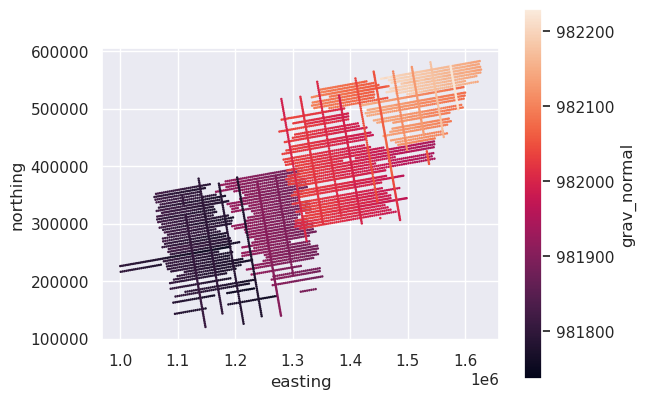

In [31]:
data_df[::50].plot.scatter(
    "easting",
    "northing",
    c="grav_normal",
    s=0.6,
).set_aspect("equal")

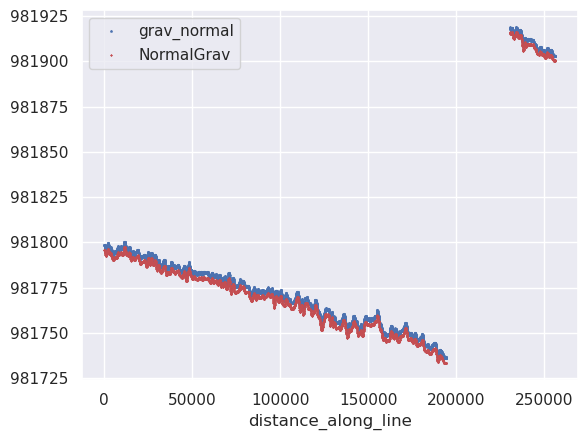

In [32]:
df = data_df[data_df.line == 1]
ax = df.plot.line(
    "distance_along_line",
    "grav_normal",
    style="bp",
    ms=1,
)
ax = df.plot.line(
    "distance_along_line",
    "NormalGrav",
    style="rx",
    ms=1,
    ax=ax,
)

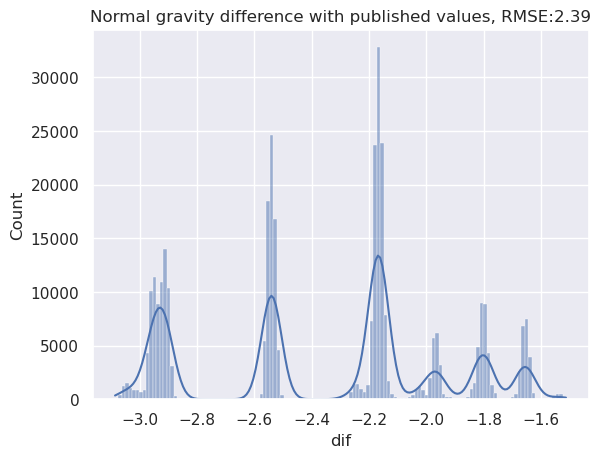

In [33]:
data_df["dif"] = data_df.NormalGrav - data_df.grav_normal
sns.histplot(data_df.dif, kde=True)
plt.title(
    f"Normal gravity difference with published values, RMSE:{round(airbornegeo.rmse(data_df.dif), 2)}"
)
plt.show()

In [34]:
# for now just use the BAS values
data_df = data_df.drop(columns=["grav_normal"], errors="ignore")
data_df["grav_normal"] = data_df.NormalGrav

## Gravity Distrubance

In [35]:
# The disturbance is the observed minus normal gravity (calculated at the
# observation point)
data_df["grav_disturbance"] = data_df.grav_observed - data_df.grav_normal

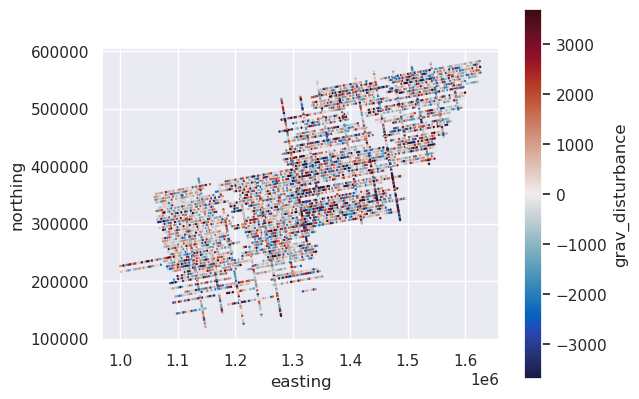

In [36]:
cpt_lims = vd.maxabs(data_df.Free_air, percentile=95)
data_df[::50].plot.scatter(
    "easting",
    "northing",
    c="grav_disturbance",
    s=0.6,
    cmap=cmocean.cm.balance,
    vmin=-cpt_lims,
    vmax=cpt_lims,
).set_aspect("equal")

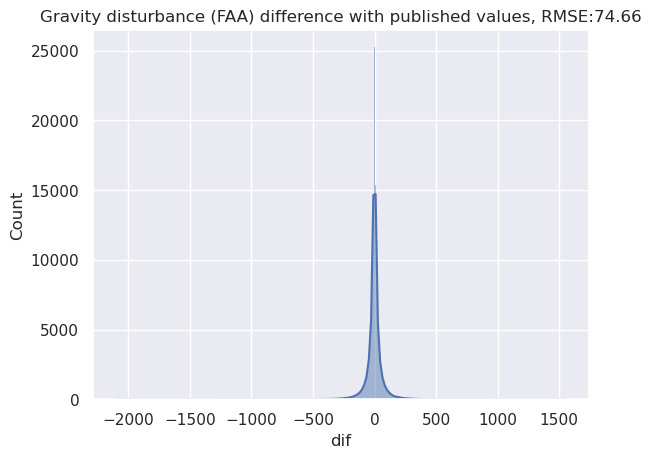

In [37]:
data_df["dif"] = data_df.Free_air - data_df.grav_disturbance
sns.histplot(data_df.dif, kde=True)
plt.title(
    f"Gravity disturbance (FAA) difference with published values, RMSE:{round(airbornegeo.rmse(data_df.dif), 2)}"
)
plt.show()

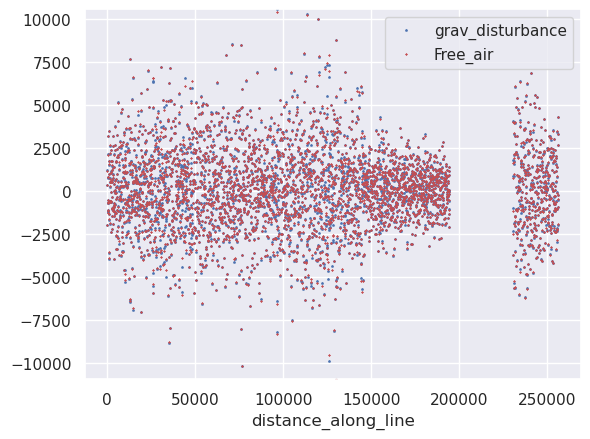

In [38]:
df = data_df[data_df.line == 1]

ylim = vd.minmax(df.grav_disturbance)  # , min_percentile=5, max_percentile=95)

ax = df.plot.line(
    "distance_along_line",
    "grav_disturbance",
    style="bp",
    ms=1,
    ylim=ylim,
)

ax = df.plot.line(
    "distance_along_line",
    "Free_air",
    style="rx",
    ms=1,
    ax=ax,
    ylim=ylim,
)

In [40]:
# for now just use the BAS values
data_df = data_df.drop(columns=["grav_disturbance"], errors="ignore")
data_df["grav_disturbance"] = data_df.Free_air

## Filtering

Filtered free air anomaly (FAA_filt) used 9 km 1/2 wavelength space domain kernel filter (Holt et al., 2006).

In [41]:
data_df["grav_disturbance_filt"] = airbornegeo.filter_line(
    data_df,
    filter_type="g26000+l",
    data_column="grav_disturbance",
    filter_by_column="distance_along_line",
    groupby_column="line",
    pad_width_percentage=20,
)

Segments: 100%|██████████| 100/100 [00:04<00:00, 21.33it/s]


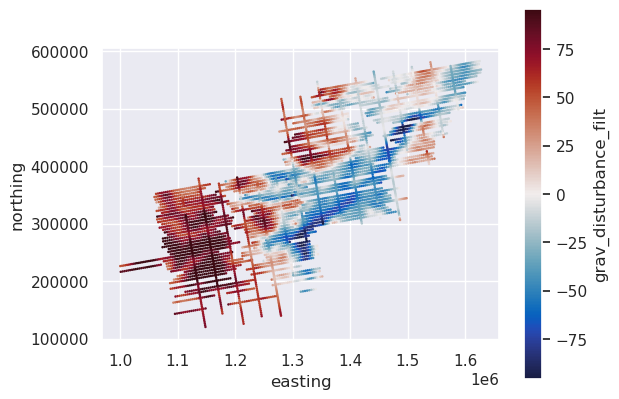

In [42]:
cpt_lims = vd.maxabs(data_df.FAA_filt, percentile=95)
data_df[::50].plot.scatter(
    "easting",
    "northing",
    c="grav_disturbance_filt",
    s=0.6,
    cmap=cmocean.cm.balance,
    vmin=-cpt_lims,
    vmax=cpt_lims,
).set_aspect("equal")

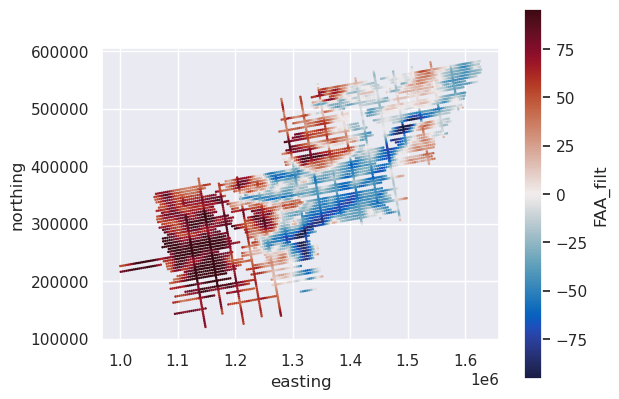

In [43]:
data_df[::50].plot.scatter(
    "easting",
    "northing",
    c="FAA_filt",
    s=0.6,
    cmap=cmocean.cm.balance,
    vmin=-cpt_lims,
    vmax=cpt_lims,
).set_aspect("equal")

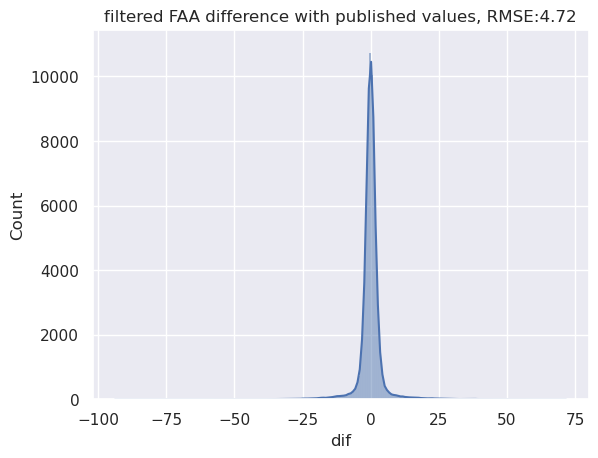

In [44]:
data_df["dif"] = data_df.FAA_filt - data_df.grav_disturbance_filt
sns.histplot(data_df.dif, kde=True)
plt.title(
    f"filtered FAA difference with published values, RMSE:{round(airbornegeo.rmse(data_df.dif), 2)}"
)
plt.show()

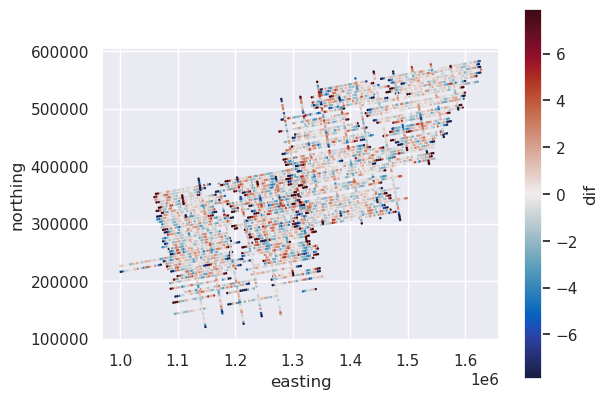

In [45]:
cpt_lims = vd.maxabs(data_df.dif, percentile=95)
data_df[::50].plot.scatter(
    "easting",
    "northing",
    c="dif",
    s=0.6,
    cmap=cmocean.cm.balance,
    vmin=-cpt_lims,
    vmax=cpt_lims,
).set_aspect("equal")

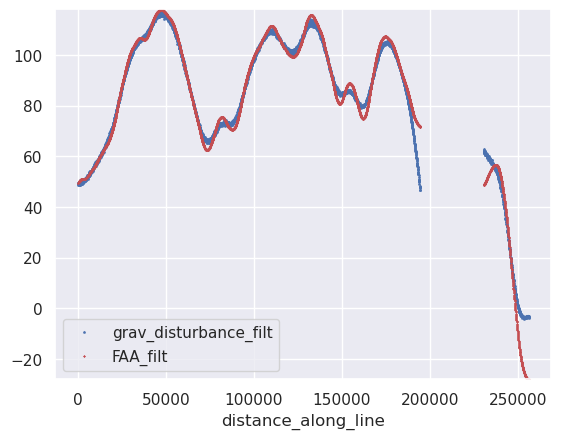

In [46]:
df = data_df[data_df.line == 1]

ylim = vd.minmax(df.FAA_filt)  # , min_percentile=5, max_percentile=95)

ax = df.plot.line(
    "distance_along_line",
    "grav_disturbance_filt",
    style="bp",
    ms=1,
    ylim=ylim,
)

ax = df.plot.line(
    "distance_along_line",
    "FAA_filt",
    style="rx",
    ms=1,
    ax=ax,
    ylim=ylim,
)

In [47]:
# for now just use the BAS values
data_df = data_df.drop(columns=["grav_disturbance_filt"], errors="ignore")
data_df["grav_disturbance_filt"] = data_df.FAA_filt

## Save the results

In [48]:
data_df.columns

Index(['Lon', 'Lat', 'Height_WGS1984', 'Date', 'Time', 'ST', 'CC', 'RB',
       'XACC', 'LACC', 'Still', 'Base', 'ST_real', 'Beam_vel', 'rec_grav',
       'Abs_grav', 'VaccCor', 'EotvosCor', 'LatCor', 'FaCor', 'HaccCor',
       'Free_air', 'FAA_filt', 'FAA_clip', 'Level_cor', 'FAA_level',
       'Fa_4600m', 'easting', 'northing', 'line_name', 'line', 'unixtime',
       'geometry', 'distance_along_line', 'grav_relative', 'grav_absolute',
       'dif', 'vertical_acceleration', 'horizontal_acceleration',
       'ground_speed', 'track', 'eotvos_correction', 'grav_observed',
       'NormalGrav', 'grav_normal', 'grav_disturbance',
       'grav_disturbance_filt'],
      dtype='str')

In [49]:
# save to csv for further levelling notebook
# eventually will use our version, but for checking the levelling is working correctly,
# we will just use their version
df = data_df

df = df.rename(
    columns={
        "Level_cor": "level_correction",
        "FAA_level": "grav_disturbance_filt_level",
        "Height_WGS1984": "height",
        "Lon": "longitude",
        "Lat": "latitude",
    }
)

df = df[
    [
        "line",
        "easting",
        "northing",
        "longitude",
        "latitude",
        "height",
        "unixtime",
        "distance_along_line",
        "grav_observed",
        "grav_disturbance",
        "grav_disturbance_filt",
        "level_correction",
        "grav_disturbance_filt_level",
    ]
]

df = df.reset_index(drop=True)
df

,line,easting,northing,longitude,latitude,height,unixtime,distance_along_line,grav_observed,grav_disturbance,grav_disturbance_filt,level_correction,grav_disturbance_filt_level
0,1,1.000024e+06,226237.330771,77.252450,-80.583923,4156.1,1.229507e+09,0.000000,982999.505,1186.4,49.38,7.03,42.4
1,1,1.000083e+06,226246.631269,77.252672,-80.583377,4156.0,1.229507e+09,59.842447,982174.380,342.1,49.45,7.04,42.4
2,1,1.000142e+06,226255.809132,77.252901,-80.582831,4156.1,1.229507e+09,119.693401,979818.700,-1965.9,49.52,7.04,42.5
3,1,1.000201e+06,226264.969079,77.253131,-80.582285,4156.4,1.229507e+09,179.545645,982577.335,820.0,49.58,7.03,42.5
4,1,1.000260e+06,226274.156809,77.253358,-80.581740,4156.6,1.229507e+09,239.285174,984988.280,3198.0,49.65,7.04,42.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
333988,100,1.587964e+06,496507.950674,72.637128,-74.773798,2112.2,1.230382e+09,78906.532032,980759.445,-1466.6,-16.89,NaN,NaN
333989,100,1.587973e+06,496454.987752,72.638964,-74.773861,2111.7,1.230382e+09,78960.299070,980939.990,-1288.3,-16.83,NaN,NaN
333990,100,1.587983e+06,496401.908627,72.640803,-74.773925,2111.2,1.230382e+09,79014.166666,983596.705,1363.5,-16.76,NaN,NaN
333991,100,1.587992e+06,496348.713306,72.642645,-74.773990,2110.6,1.230382e+09,79068.134996,983842.245,1616.2,-16.69,NaN,NaN


In [50]:
df.to_csv("data/AGAP_gravity_survey_processed.csv", index=False)

In [ ]:
# # block reduce by line to speed up the notebooks
# df_blocked = airbornegeo.block_reduce(
#     df,
#     np.median,
#     spacing=100,
#     reduce_by="distance_along_line",
#     groupby_column="line",
# )
# df_blocked

In [ ]:
# df_blocked.to_csv("data/AGAP_gravity_survey_processed_blocked.csv", index=False)

## Grid the levelled data

In [ ]:
# df_blocked = pd.read_csv("data/AGAP_gravity_survey_processed_blocked.csv")

In [ ]:
# import harmonica as hm
# import polartoolkit as ptk
# import verde as vd

# coords = (
#     df_blocked.easting,
#     df_blocked.northing,
#     df_blocked.Height_WGS1984,
# )
# eqs = hm.EquivalentSources(damping=0.1, depth="default", block_size=20e3)
# eqs.fit(coords, df_blocked.grav_disturbance_filt_level)

In [ ]:
# # Define grid coordinates
# grid_coords = vd.grid_coordinates(
#     region=vd.pad_region(vd.get_region(coords), 50e3),
#     spacing=2000,
#     extra_coords=4200,  # upward continue
#     adjust="region",
# )
# grid = eqs.grid(grid_coords)

# grid = vd.distance_mask((coords[0], coords[1]), maxdist=10e3, grid=grid)
# grid = grid.reset_coords(names="upward").scalars
# grid.plot(robust=True)

In [ ]:
# east_deriv = airbornegeo.filter_grid(grid, filter_type="easting_deriv")
# north_deriv = airbornegeo.filter_grid(grid, filter_type="northing_deriv")
# up_deriv = airbornegeo.filter_grid(grid, filter_type="up_deriv")
# total_gradient = airbornegeo.filter_grid(grid, filter_type="total_gradient")

# fig = ptk.subplots(
#     [east_deriv, north_deriv, up_deriv, total_gradient],
#     fig_title="Levelled grid derivatives",
#     titles=[
#         "Easting derivative",
#         "Northing derivative",
#         "Upward derivative",
#         "Total gradient",
#     ],
#     cmap="balance+h0",
#     robust=True,
#     fig_height=10,
#     epsg="3031",
# )
# fig.show()